### Conceptual Recursive Book Cover Drawing

This is a classic example of recursion where a smaller version of the whole is contained within itself. To `draw_book_cover_with_person_holding_book`, you'd essentially:

1.  Draw the main person.
2.  Draw the main book in their hands.
3.  *Inside* the main book's cover, recursively call the same function to draw a smaller person holding a smaller book.

This continues until a base case is met (e.g., the book becomes too small to draw detail).

In [ ]:
def draw_book_cover_recursive(level, max_level=5):
    """
    A conceptual recursive function to describe drawing a book cover
    with a person holding the same book.

    Args:
        level (int): The current recursion level (depth of nesting).
        max_level (int): The maximum depth of recursion.
    """

    if level > max_level:
        # Base case: Stop recursion when the detail is too small to draw
        print(f"  {'  ' * (level - 1)}[STOP] Book cover at level {level} is too small to draw details.")
        return

    indent = '  ' * (level - 1)
    print(f"{indent}Level {level}: Drawing book cover.")
    print(f"{indent}  - Drawing person for book cover {level}.")
    print(f"{indent}  - Drawing book {level} in the person's hands.")
    print(f"{indent}    -- Inside book {level}'s cover, depicting a scene...")

    # Recursive step: Draw a smaller version inside the current book's cover
    draw_book_cover_recursive(level + 1, max_level)

    if level == 1:
        print("\nConceptual drawing complete!")

# Initiate the recursive drawing process
print("Starting conceptual recursive book cover drawing:\n")
draw_book_cover_recursive(1)

Starting conceptual recursive book cover drawing:

Level 1: Drawing book cover.
  - Drawing person for book cover 1.
  - Drawing book 1 in the person's hands.
    -- Inside book 1's cover, depicting a scene...
  Level 2: Drawing book cover.
    - Drawing person for book cover 2.
    - Drawing book 2 in the person's hands.
      -- Inside book 2's cover, depicting a scene...
    Level 3: Drawing book cover.
      - Drawing person for book cover 3.
      - Drawing book 3 in the person's hands.
        -- Inside book 3's cover, depicting a scene...
      Level 4: Drawing book cover.
        - Drawing person for book cover 4.
        - Drawing book 4 in the person's hands.
          -- Inside book 4's cover, depicting a scene...
        Level 5: Drawing book cover.
          - Drawing person for book cover 5.
          - Drawing book 5 in the person's hands.
            -- Inside book 5's cover, depicting a scene...
            [STOP] Book cover at level 6 is too small to draw details.

Co

In [ ]:
def draw_book_cover_recursive(level, max_level=5):
    if level > max_level:
        print(f"  {'  ' * (level - 1)}[STOP] Book cover at level {level} is too small to draw details.")
        return

    indent = '  ' * (level - 1)
    print(f"{indent}Level {level}")
    print(f"{indent}  - Drawing person for book cover {level}.")
    print(f"{indent}  - Drawing book {level} in the person's hands.")

    draw_book_cover_recursive(level + 1, max_level)
draw_book_cover_recursive(1, 3)

Level 1
  - Drawing person for book cover 1.
  - Drawing book 1 in the person's hands.
  Level 2
    - Drawing person for book cover 2.
    - Drawing book 2 in the person's hands.
    Level 3
      - Drawing person for book cover 3.
      - Drawing book 3 in the person's hands.
        [STOP] Book cover at level 4 is too small to draw details.


In [2]:
def draw_book_cover_recursive(level, max_level=5):
    if level > max_level:
        return
    indent = '  ' * (level - 1)
    print(f"{indent}Level {level} Draw a boy holing the same book")
    draw_book_cover_recursive(level + 1, max_level)

draw_book_cover_recursive(1, 3)

Level 1 Draw a boy holing the same book
  Level 2 Draw a boy holing the same book
    Level 3 Draw a boy holing the same book


### Drawing a Conceptual Person with Matplotlib

This code uses `matplotlib` to draw a simple representation of a person, using a circle for the head and a line for one arm. This demonstrates how basic shapes can be plotted.

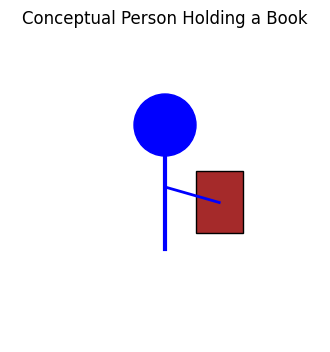

In [ ]:
import matplotlib.pyplot as plt

# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(4, 6))

# Draw the head as a circle
head = plt.Circle((0.5, 0.7), 0.1, color='blue') # (x, y) center, radius
ax.add_patch(head)

# Draw the body as a line (simplified)
ax.plot([0.5, 0.5], [0.6, 0.3], color='blue', linewidth=3) # Vertical line for body

# Draw the book as a rectangle
book_width = 0.15
book_height = 0.2
book_x = 0.6 # Position the book next to the body
book_y = 0.35 # Position the book vertically
book = plt.Rectangle((book_x, book_y), book_width, book_height, color='brown', ec='black') # ec for edge color
ax.add_patch(book)

# Draw one hand/arm holding the book
# Adjust coordinates to connect arm to body and extend to book
ax.plot([0.5, book_x + book_width / 2], [0.5, book_y + book_height / 2], color='blue', linewidth=2) # Arm reaching towards the center of the book

# Set plot limits and aspect ratio
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal', adjustable='box') # Keep circles looking circular

# Remove axes for a cleaner look
ax.axis('off')

# Add a title
ax.set_title('Conceptual Person Holding a Book')

# Display the plot
plt.show()

### Recursive Book Cover Drawing with Matplotlib

To visualize the recursive book cover, we'll create a function that draws the person and their book. Inside this function, for each level of recursion, it will then call itself to draw a smaller person holding a smaller book, positioned *within* the previous book's cover. This demonstrates the fractal-like nature of the problem.

**Note**: The precise geometric placement and scaling for visually perfect recursion can be complex. This example provides a conceptual visual representation by scaling down and offsetting the nested drawings.

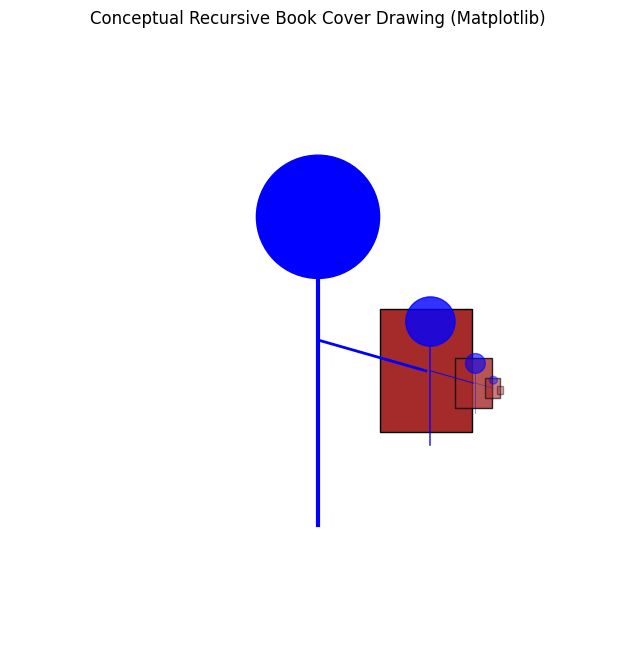

In [ ]:
import matplotlib.pyplot as plt

def draw_person_holding_book_recursive(ax, center_x, center_y, scale_factor, current_level, max_level=3):
    """
    Recursively draws a person holding a book, with smaller versions inside.

    Args:
        ax (matplotlib.axes.Axes): The axes to draw on.
        center_x (float): The x-coordinate of the center of the current drawing's person.
        center_y (float): The y-coordinate of the center of the current drawing's person.
        scale_factor (float): The current scaling factor for the drawing.
        current_level (int): The current recursion level.
        max_level (int): The maximum depth of recursion.
    """

    if current_level > max_level:
        return

    # Use alpha to make deeper levels slightly transparent
    alpha_val = 1.0 - (current_level - 1) * 0.2
    if alpha_val < 0.1: # Don't go too transparent
        alpha_val = 0.1

    # Define base dimensions (relative to scale_factor = 1.0)
    base_head_radius = 0.1
    base_body_length = 0.3
    base_book_width = 0.15
    base_book_height = 0.2
    base_book_offset_x = 0.1 # From person's center-line
    base_book_offset_y = -0.15 # From person's center-line

    # Scale components
    head_radius = base_head_radius * scale_factor
    body_start_y = center_y + (0.1 * scale_factor) # Relative to person's center
    body_end_y = center_y - (base_body_length * scale_factor)

    book_width_scaled = base_book_width * scale_factor
    book_height_scaled = base_book_height * scale_factor
    book_x_scaled = center_x + (base_book_offset_x * scale_factor)
    book_y_scaled = center_y + (base_book_offset_y * scale_factor)

    # Draw head
    head = plt.Circle((center_x, center_y + (0.2 * scale_factor)), head_radius, color='blue', alpha=alpha_val)
    ax.add_patch(head)

    # Draw body
    ax.plot([center_x, center_x], [body_start_y, body_end_y], color='blue', linewidth=3 * scale_factor, alpha=alpha_val)

    # Draw book
    book = plt.Rectangle((book_x_scaled, book_y_scaled), book_width_scaled, book_height_scaled,
                         color='brown', ec='black', alpha=alpha_val)
    ax.add_patch(book)

    # Draw arm holding the book
    arm_start_x = center_x # From body center
    arm_start_y = center_y # From body center
    arm_end_x = book_x_scaled + book_width_scaled / 2
    arm_end_y = book_y_scaled + book_height_scaled / 2
    ax.plot([arm_start_x, arm_end_x], [arm_start_y, arm_end_y], color='blue', linewidth=2 * scale_factor, alpha=alpha_val)

    # Recursive step: Draw a smaller version inside the current book's cover
    # We need to calculate the new center and scale for the nested drawing
    nested_scale_factor = scale_factor * 0.4 # Shrink by 60% for the next level

    # Place the nested drawing conceptually within the book's cover area
    # Let's put its center slightly to the right and up within the current book.
    nested_center_x = book_x_scaled + book_width_scaled * 0.55
    nested_center_y = book_y_scaled + book_height_scaled * 0.5

    draw_person_holding_book_recursive(ax, nested_center_x, nested_center_y,
                                       nested_scale_factor, current_level + 1, max_level)


# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(8, 8))

# Initial call to draw the outermost scene
# Starting from the center of the plot area, with full scale (1.0)
draw_person_holding_book_recursive(ax, 0.5, 0.5, 1.0, 1, max_level=4)

# Set plot limits and aspect ratio
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal', adjustable='box') # Keep circles looking circular

# Remove axes for a cleaner look
ax.axis('off')

# Add a title
ax.set_title('Conceptual Recursive Book Cover Drawing (Matplotlib)')

# Display the plot
plt.show()